In [ ]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV, learning_curve, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
import warnings
import os

In [ ]:
url = "https://raw.githubusercontent.com/screamkface/Repo-for-gtzan-dataset/refs/heads/main/features_3_sec.csv"

print("⏳ Downloading and reading the dataset...")

try:
    df = pd.read_csv(url)

    df.to_csv('features_3_sec.csv', index=False)

    print(f"✅ Success! Dataset loaded.")
    print(f"Dimensions: {df.shape}")
    print(df.head(3))

except Exception as e:
    print(f"❌ Error: {e}")

⏳ Downloading and reading the dataset...
✅ Success! Dataset loaded.
Dimensions: (9990, 60)
            filename  length  chroma_stft_mean  chroma_stft_var  rms_mean  \
0  blues.00000.0.wav   66149          0.335406         0.091048  0.130405   
1  blues.00000.1.wav   66149          0.343065         0.086147  0.112699   
2  blues.00000.2.wav   66149          0.346815         0.092243  0.132003   

    rms_var  spectral_centroid_mean  spectral_centroid_var  \
0  0.003521             1773.065032          167541.630869   
1  0.001450             1816.693777           90525.690866   
2  0.004620             1788.539719          111407.437613   

   spectral_bandwidth_mean  spectral_bandwidth_var  ...  mfcc16_var  \
0              1972.744388           117335.771563  ...   39.687145   
1              2010.051501            65671.875673  ...   64.748276   
2              2084.565132            75124.921716  ...   67.336563   

   mfcc17_mean  mfcc17_var  mfcc18_mean  mfcc18_var  mfcc19_mean  

In [ ]:
# Pulizia warning
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

In [ ]:
try:
    df = pd.read_csv('/content/features_3_sec.csv')
except FileNotFoundError:
    print("Error: File not found.")
    exit()

df['song_id'] = df['filename'].apply(lambda x: '.'.join(x.split('.')[:2]))
df = df.dropna()

print(f"Dataset loaded: {df.shape[0]} segments, {df.shape[1]-4} features")
print(f"Unique songs: {df['song_id'].nunique()}")
print(f"Genres: {df['label'].nunique()}")

print("\nGenre distribution:")
print(df['label'].value_counts())

print("\nSongs per genre:")
songs_per_genre = df.groupby('label')['song_id'].nunique()
print(songs_per_genre)
print(f"Min songs per genre: {songs_per_genre.min()}")

Dataset loaded: 9990 segments, 57 features
Unique songs: 1000
Genres: 10

Genre distribution:
label
blues        1000
jazz         1000
pop          1000
reggae       1000
metal        1000
disco         999
classical     998
hiphop        998
rock          998
country       997
Name: count, dtype: int64

Songs per genre:
label
blues        100
classical    100
country      100
disco        100
hiphop       100
jazz         100
metal        100
pop          100
reggae       100
rock         100
Name: song_id, dtype: int64
Min songs per genre: 100


In [ ]:
le = LabelEncoder()
y_encoded = le.fit_transform(df['label'])
groups = df['song_id']
X = df.drop(columns=['filename', 'length', 'label', 'song_id'])

print("Creating stratified train/test split...")
sgkf = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=42)
train_idx, test_idx = next(sgkf.split(X, y_encoded, groups=groups))

X_train = X.iloc[train_idx]
y_train = y_encoded[train_idx]
X_test = X.iloc[test_idx]
y_test = y_encoded[test_idx]
train_groups = df.iloc[train_idx]['song_id']

print(f"Training set: {X_train.shape[0]} samples, {len(np.unique(train_groups))} unique songs")
print(f"Test set: {X_test.shape[0]} samples, {len(np.unique(df.iloc[test_idx]['song_id']))} unique songs")

print("Standardizing features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Creating stratified train/test split...
Training set: 7493 samples, 750 unique songs
Test set: 2497 samples, 250 unique songs
Standardizing features...


In [ ]:
models_to_run = [
    {
        'name': 'Softmax Regression',
        'estimator': LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=2000, random_state=42),
        'param_grid': {'C': [0.1, 1, 10]}
    },
    {
        'name': 'Decision Tree',
        'estimator': DecisionTreeClassifier(random_state=42),
        'param_grid': {
            'max_depth': [5, 10, 20],
            'min_samples_leaf': [1, 5, 10],
            'criterion': ['gini', 'entropy']
        }
    },
    {
        'name': 'Random Forest',
        'estimator': RandomForestClassifier(random_state=42),
        'param_grid': {
            'n_estimators': [100, 200],
            'max_depth': [10, 25],
            'min_samples_leaf': [1, 3]
        }
    },
    {
        'name': 'Naïve Bayes (Gaussian)',
        'estimator': GaussianNB(),
        'param_grid': {'var_smoothing': [1e-9, 1e-7, 1e-5]}
    },
    {
        'name': 'SVM (Linear)',
        'estimator': LinearSVC(dual=False, random_state=42, max_iter=3000),
        'param_grid': {'C': [0.1, 1, 10]}
    },
    {
        'name': 'SVM (Kernel RBF)',
        'estimator': SVC(kernel='rbf', random_state=42, probability=True),
        'param_grid': {'C': [1, 10], 'gamma': [0.01, 'scale']}
    }
]

cv_splitter = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=42)
results = []
trained_models = []

print(f"Starting training for {len(models_to_run)} models...")
for model_info in models_to_run:
    model_name = model_info['name']
    estimator = model_info['estimator']
    param_grid = model_info['param_grid']

    print(f"\n--- Training: {model_name} ---")
    start_time = time.time()

    grid_search = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        cv=cv_splitter,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=1
    )

    grid_search.fit(X_train_scaled, y_train, groups=train_groups)

    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test_scaled)

    test_acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True)

    results.append({
        'Model': model_name,
        'Accuracy': test_acc,
        'Precision': report['macro avg']['precision'],
        'Recall': report['macro avg']['recall'],
        'Macro F1': report['macro avg']['f1-score'],
        'Best Params': grid_search.best_params_,
        'CV Score': grid_search.best_score_,
        'Time (s)': time.time() - start_time
    })

    trained_models.append({
        'name': model_name,
        'model': best_model,
        'predictions': y_pred
    })

    print(f"Completed: {model_name} (Accuracy: {test_acc:.3f})")

Starting training for 6 models...

--- Training: Softmax Regression ---
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Completed: Softmax Regression (Accuracy: 0.684)

--- Training: Decision Tree ---
Fitting 3 folds for each of 18 candidates, totalling 54 fits
Completed: Decision Tree (Accuracy: 0.545)

--- Training: Random Forest ---
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Completed: Random Forest (Accuracy: 0.710)

--- Training: Naïve Bayes (Gaussian) ---
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Completed: Naïve Bayes (Gaussian) (Accuracy: 0.518)

--- Training: SVM (Linear) ---
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Completed: SVM (Linear) (Accuracy: 0.672)

--- Training: SVM (Kernel RBF) ---
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Completed: SVM (Kernel RBF) (Accuracy: 0.736)


In [ ]:
summary_df = pd.DataFrame(results).set_index('Model').sort_values('Accuracy', ascending=False)
print("🏆 FINAL COMPARATIVE REPORT 🏆")
print(summary_df[['Accuracy', 'Precision', 'Recall', 'Macro F1', 'CV Score', 'Time (s)']].round(4))

print("\n--- Best Parameters ---")
for r in results:
    print(f"{r['Model']}: {r['Best Params']}")

🏆 FINAL COMPARATIVE REPORT 🏆
                        Accuracy  Precision  Recall  Macro F1  CV Score  \
Model                                                                     
SVM (Kernel RBF)          0.7365     0.7388  0.7364    0.7360    0.6894   
Random Forest             0.7097     0.7063  0.7091    0.7047    0.6639   
Softmax Regression        0.6840     0.6809  0.6831    0.6808    0.6455   
SVM (Linear)              0.6720     0.6624  0.6712    0.6639    0.6258   
Decision Tree             0.5455     0.5440  0.5453    0.5423    0.4872   
Naïve Bayes (Gaussian)    0.5178     0.5213  0.5161    0.4995    0.4748   

                        Time (s)  
Model                             
SVM (Kernel RBF)         81.8085  
Random Forest           165.3451  
Softmax Regression        7.1367  
SVM (Linear)              5.5070  
Decision Tree            29.8726  
Naïve Bayes (Gaussian)    0.3579  

--- Best Parameters ---
Softmax Regression: {'C': 0.1}
Decision Tree: {'criterion': 'entr


=== DETAILED ANALYSIS ===
Generating learning curves...


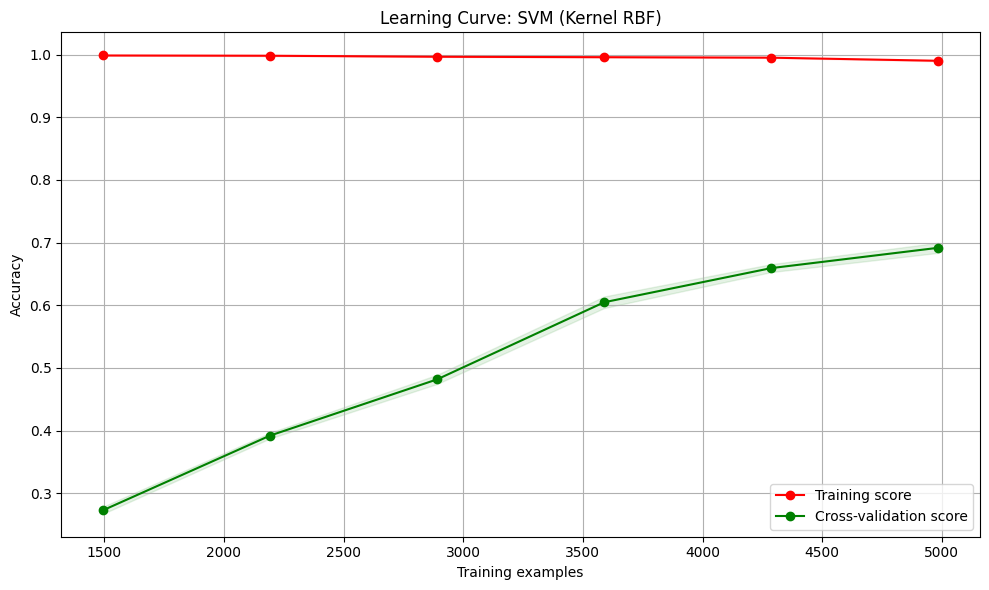

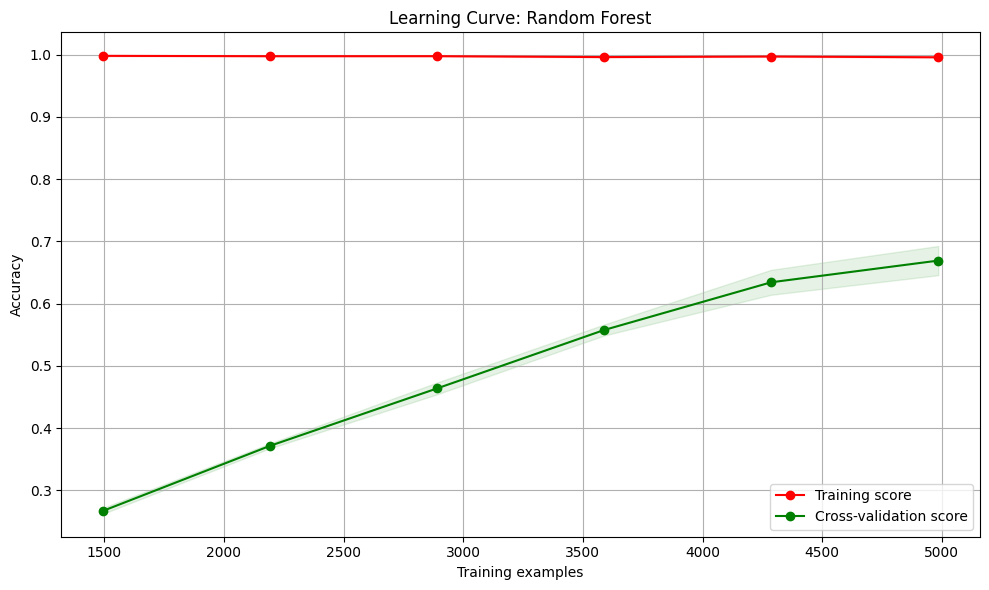

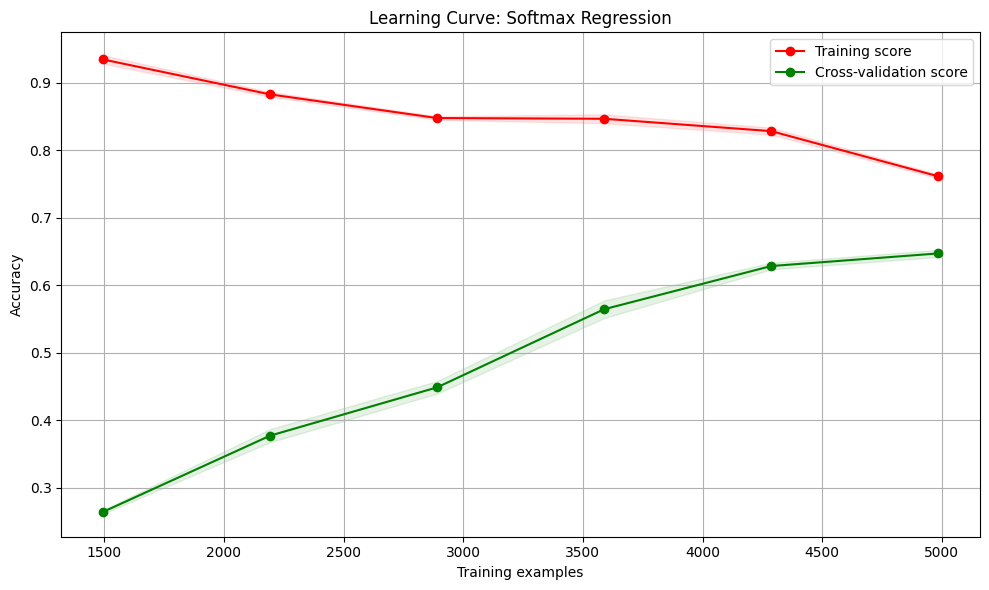

Generating confusion matrices for TOP 3 performing models...


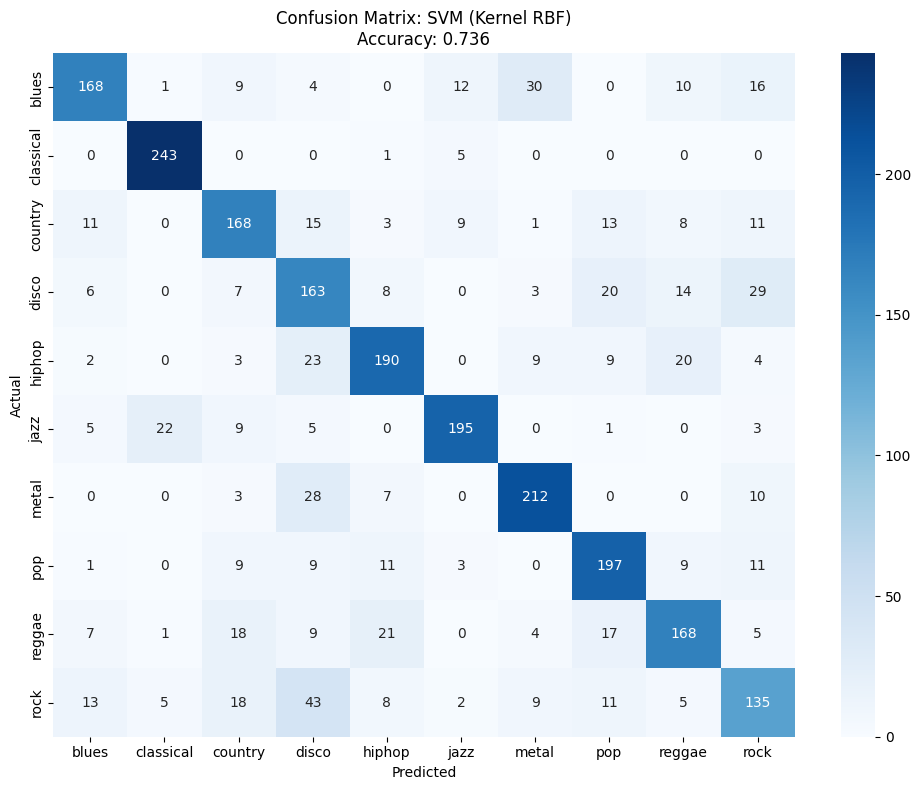

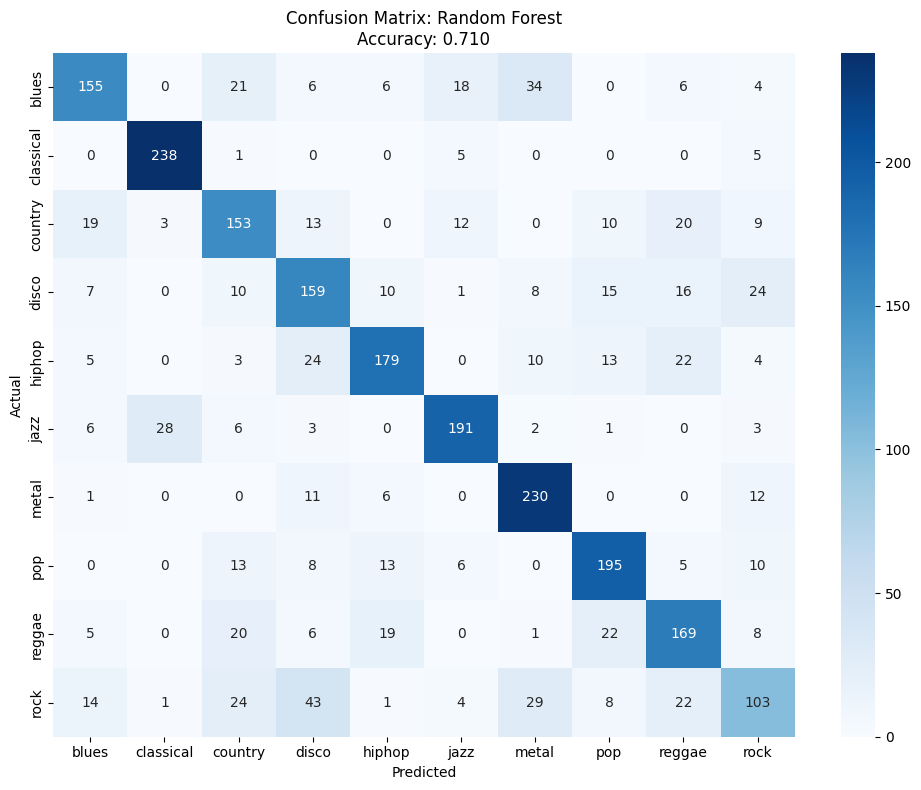

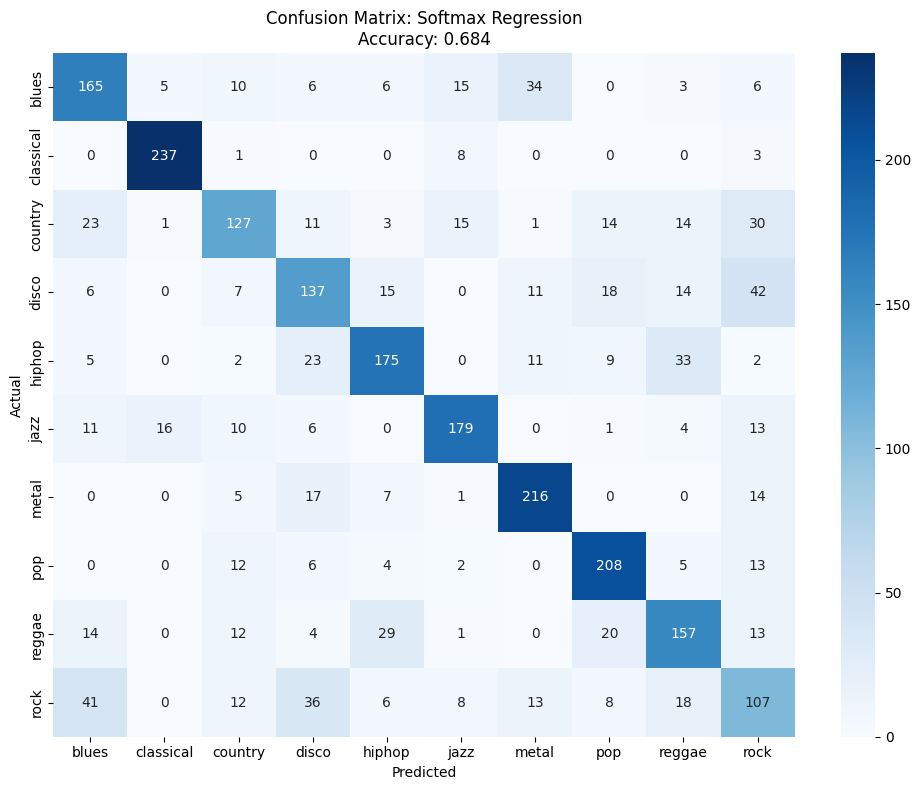

Generating ROC Curves for the Best Model...


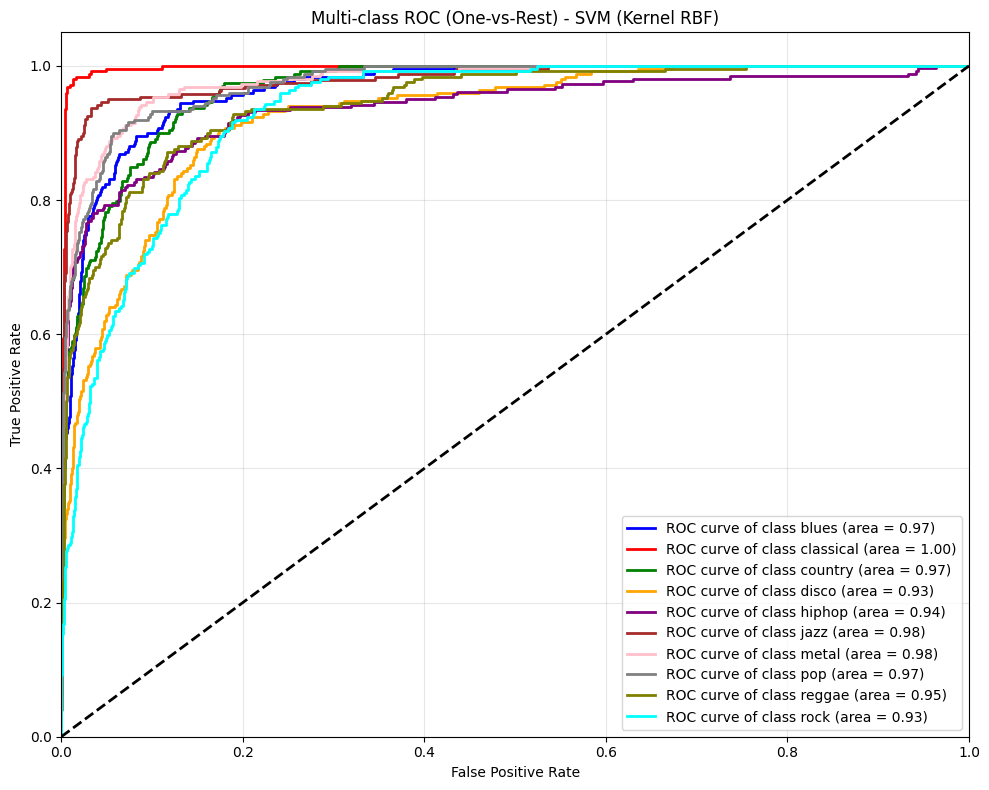

Analyzing feature importance...


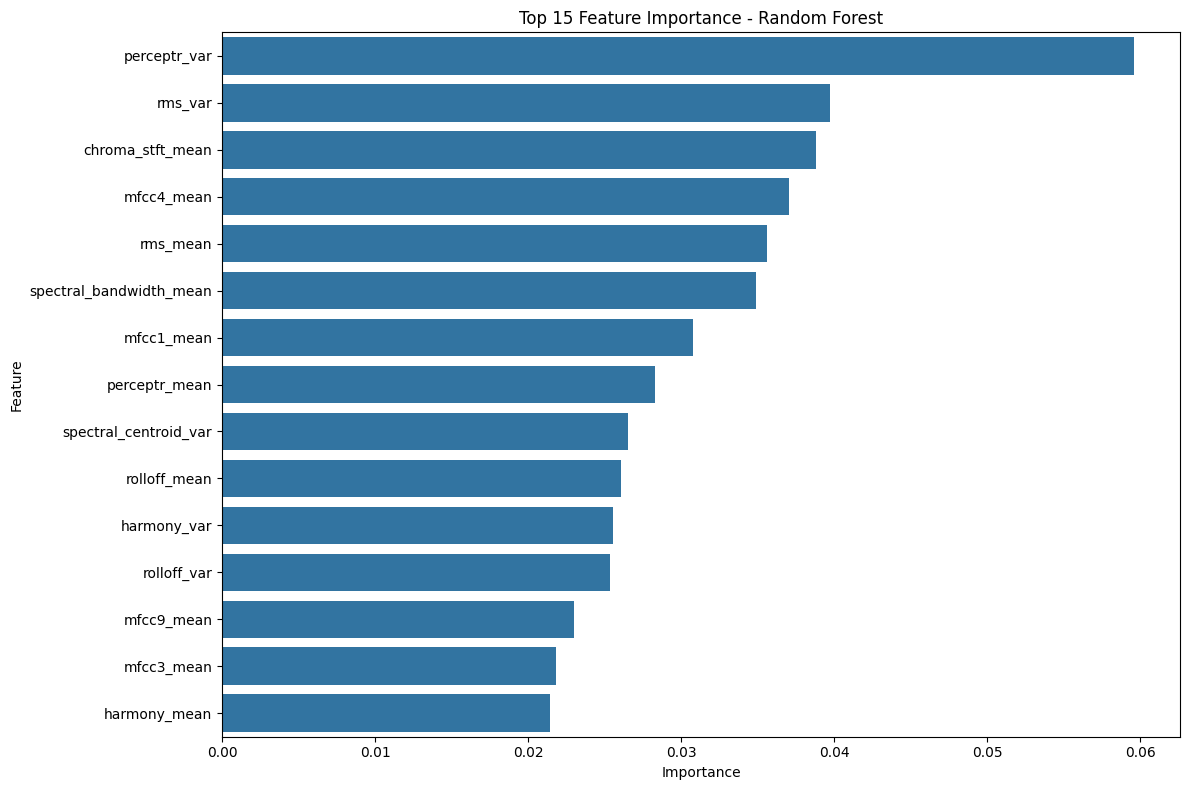


Top 10 Random Forest features:
                    Feature  Importance
15             perceptr_var    0.059608
3                   rms_var    0.039691
0          chroma_stft_mean    0.038826
23               mfcc4_mean    0.037066
2                  rms_mean    0.035623
6   spectral_bandwidth_mean    0.034902
17               mfcc1_mean    0.030740
14            perceptr_mean    0.028293
5     spectral_centroid_var    0.026518
8              rolloff_mean    0.026098


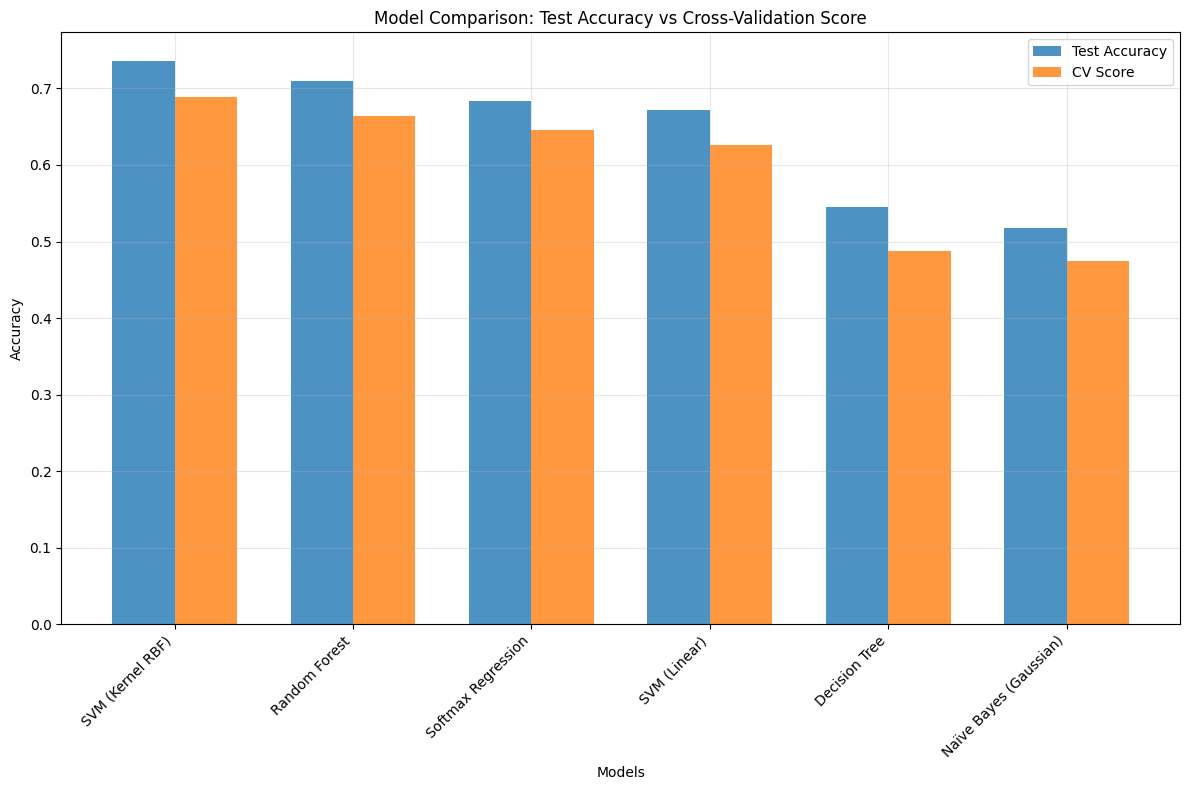

In [ ]:
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import learning_curve
from sklearn.metrics import confusion_matrix, accuracy_score
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from itertools import cycle

print("\n=== DETAILED ANALYSIS ===")

def plot_enhanced_learning_curve(estimator, title, X, y, cv, groups, model_name):
    try:
        plt.close('all')
        plt.figure(figsize=(10, 6))

        train_sizes = np.linspace(0.3, 1.0, 6)
        train_sizes, train_scores, test_scores = learning_curve(
            estimator, X, y, cv=cv, groups=groups, n_jobs=-1,
            scoring='accuracy', train_sizes=train_sizes, random_state=42
        )

        train_mean = np.mean(train_scores, axis=1)
        train_std = np.std(train_scores, axis=1)
        test_mean = np.mean(test_scores, axis=1)
        test_std = np.std(test_scores, axis=1)

        plt.plot(train_sizes, train_mean, 'o-', color='red', label='Training score')
        plt.plot(train_sizes, test_mean, 'o-', color='green', label='Cross-validation score')
        plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='red')
        plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='green')

        plt.title(f'Learning Curve: {title}')
        plt.xlabel('Training examples')
        plt.ylabel('Accuracy')
        plt.legend(loc='best')
        plt.grid(True)
        plt.tight_layout()
        display(plt.gcf())
        plt.close()
        return True
    except Exception as e:
        print(f"Could not generate learning curve for {model_name}: {e}")
        return False

# --- Learning Curves ---
print("Generating learning curves...")
top_models = summary_df.head(3).index
for model_name in top_models:
    model_info = next((m for m in trained_models if m['name'] == model_name), None)
    if model_info:
        plot_enhanced_learning_curve(
            model_info['model'],
            model_name,
            X_train_scaled, y_train,
            cv_splitter, train_groups,
            model_name
        )

# --- Confusion Matrices ---
print("Generating confusion matrices for TOP 3 performing models...")
plt.close('all')

top_models_names = summary_df.head(3).index

for model_name in top_models_names:
    model_info = next((m for m in trained_models if m['name'] == model_name), None)

    if model_info:
        y_pred = model_info['predictions']
        cm = confusion_matrix(y_test, y_pred)

        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=le.classes_, yticklabels=le.classes_)
        plt.title(f'Confusion Matrix: {model_info["name"]}\nAccuracy: {accuracy_score(y_test, y_pred):.3f}')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.tight_layout()
        display(plt.gcf())
        plt.close()
    else:
        print(f"Warning: Data for {model_name} not found.")

# --- ROC Curves ---
print("Generating ROC Curves for the Best Model...")
best_model_name = summary_df.index[0]
best_model_data = next((m for m in trained_models if m['name'] == best_model_name), None)

if best_model_data and hasattr(best_model_data['model'], 'predict_proba'):
    try:
        y_test_bin = label_binarize(y_test, classes=range(len(le.classes_)))
        n_classes = y_test_bin.shape[1]
        y_score = best_model_data['model'].predict_proba(X_test_scaled)

        fpr = dict()
        tpr = dict()
        roc_auc = dict()
        for i in range(n_classes):
            fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])

        plt.figure(figsize=(10, 8))
        colors = cycle(['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan'])

        for i, color in zip(range(n_classes), colors):
            plt.plot(fpr[i], tpr[i], color=color, lw=2,
                     label='ROC curve of class {0} (area = {1:0.2f})'
                     ''.format(le.classes_[i], roc_auc[i]))

        plt.plot([0, 1], [0, 1], 'k--', lw=2)
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'Multi-class ROC (One-vs-Rest) - {best_model_name}')
        plt.legend(loc="lower right")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        display(plt.gcf())
        plt.close()

    except Exception as e:
        print(f"Could not generate ROC curve: {e}")
else:
    print(f"Skipping ROC: Best model ({best_model_name}) does not support predict_proba.")

# --- Feature Importance ---
print("Analyzing feature importance...")
feature_names = X.columns
rf_model = next((m['model'] for m in trained_models if m['name'] == 'Random Forest'), None)

if rf_model and hasattr(rf_model, 'feature_importances_'):
    rf_importance = pd.DataFrame({
        'Feature': feature_names,
        'Importance': rf_model.feature_importances_
    }).sort_values('Importance', ascending=False)

    plt.figure(figsize=(12, 8))
    sns.barplot(data=rf_importance.head(15), y='Feature', x='Importance')
    plt.title('Top 15 Feature Importance - Random Forest')
    plt.tight_layout()
    display(plt.gcf())
    plt.close()

    print("\nTop 10 Random Forest features:")
    print(rf_importance.head(10))

# --- Model Comparison ---
plt.figure(figsize=(12, 8))
models = summary_df.index
accuracies = summary_df['Accuracy']
cv_scores = summary_df['CV Score']

x = np.arange(len(models))
width = 0.35

plt.bar(x - width/2, accuracies, width, label='Test Accuracy', alpha=0.8)
plt.bar(x + width/2, cv_scores, width, label='CV Score', alpha=0.8)

plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Model Comparison: Test Accuracy vs Cross-Validation Score')
plt.xticks(x, models, rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
display(plt.gcf())
plt.close()

In [ ]:
print("\n=== COMPUTATIONAL ANALYSIS ===")
computational_df = summary_df[['Time (s)', 'Accuracy']].copy()
computational_df['Efficiency'] = computational_df['Accuracy'] / computational_df['Time (s)']
computational_df = computational_df.sort_values('Efficiency', ascending=False)

print("Computational Efficiency (Accuracy per second):")
print(computational_df[['Time (s)', 'Accuracy', 'Efficiency']].round(4))


=== COMPUTATIONAL ANALYSIS ===
Computational Efficiency (Accuracy per second):
                        Time (s)  Accuracy  Efficiency
Model                                                 
Naïve Bayes (Gaussian)    0.3579    0.5178      1.4469
SVM (Linear)              5.5070    0.6720      0.1220
Softmax Regression        7.1367    0.6840      0.0958
Decision Tree            29.8726    0.5455      0.0183
SVM (Kernel RBF)         81.8085    0.7365      0.0090
Random Forest           165.3451    0.7097      0.0043


CNN's Implementation

In [ ]:
!git clone https://github.com/screamkface/Repo-for-gtzan-dataset.git

import os
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# 2. Definizione del percorso
# Il percorso punterà alla cartella images_original all'interno della repo clonata
DATA_DIR = "/content/Repo-for-gtzan-dataset/images_original"

Cloning into 'Repo-for-gtzan-dataset'...
remote: Enumerating objects: 1004, done.
remote: Total 1004 (delta 0), reused 0 (delta 0), pack-reused 1004 (from 2)
Receiving objects: 100% (1004/1004), 70.33 MiB | 20.22 MiB/s, done.
Updating files: 100% (1001/1001), done.


In [ ]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# 1. Caricamento Dataset da GitHub
if not os.path.exists("Repo-for-gtzan-dataset"):
    !git clone https://github.com/screamkface/Repo-for-gtzan-dataset.git

DATA_DIR = "/content/Repo-for-gtzan-dataset/images_original"
IMG_SIZE = (224, 224) # Aumentiamo la risoluzione per catturare più dettagli
BATCH_SIZE = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Ottimizzazione Pipeline
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# 2. Data Augmentation Avanzata
# Essenziale per contrastare l'overfitting visto nei grafici precedenti [cite: 37]
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal"),
  layers.RandomRotation(0.1),
  layers.RandomZoom(0.1),
  layers.RandomContrast(0.1)
])

# 3. Architettura CNN Migliorata
model = models.Sequential([
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    data_augmentation,
    layers.Rescaling(1./255), # Normalizzazione [cite: 13]

    # Blocco 1
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Blocco 2
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Blocco 3
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Blocco 4
    layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling2D(), # Riduce drasticamente i parametri

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5), # Protezione contro overfitting [cite: 37]
    layers.Dense(10, activation='softmax')
])

# 4. Ottimizzatore con Learning Rate controllato
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Addestramento con Early Stopping
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50, # Aumentiamo le epoche dato il learning rate basso
    callbacks=[early_stop]
)

Found 999 files belonging to 10 classes.
Using 800 files for training.
Found 999 files belonging to 10 classes.
Using 199 files for validation.
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 178s 7s/step - accuracy: 0.1663 - loss: 2.2292 - val_accuracy: 0.0754 - val_loss: 2.3246
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 164s 7s/step - accuracy: 0.2663 - loss: 2.0281 - val_accuracy: 0.0754 - val_loss: 2.4220
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 201s 7s/step - accuracy: 0.3749 - loss: 1.8454 - val_accuracy: 0.0754 - val_loss: 2.6343
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 202s 7s/step - accuracy: 0.3774 - loss: 1.8010 - val_accuracy: 0.0754 - val_loss: 3.0633
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 166s 7s/step - accuracy: 0.3963 - loss: 1.7258 - val_accuracy: 0.0754 - val_loss: 3.7605
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 167s 7s/step - accuracy: 0.4222 - loss: 1.6425 - val_accuracy: 0.0754 - val_loss: 4.5737
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 164s 7s/step - accuracy: 0.4378 - loss: 1.6265 - val_acc